# 4. ETL tabla 'users'

Partiendo de la conexión de Python con la página web de Kaggle a través de la librería 'kagglehub', hemos descargado el archivo 'users_data.csv' del conjunto de datos llamado 'Financial Transactions Dataset: Analytics'. Procederemos a limpiarlo, transformarlo, y le haremos un análisis exploratorio.

### Librerías importadas

In [1]:
import kagglehub
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import statistics as stat
import scipy.stats
from scipy.stats import pearsonr
import reverse_geocoder as rg
from dotenv import load_dotenv
from pathlib import Path

### Constantes

* Directorio actual del script de Python

In [2]:
# Consultamos el directorio actual de trabajo y lo guardamos en la constante 'CURRENT_DIRECTORY'
CURRENT_DIRECTORY=os.getcwd()
CURRENT_DIRECTORY

'C:\\Users\\yanig\\Python_Unicorn\\Proyecto_integrador'

* Directorio de la carpeta 'files'

In [3]:
# Creamos una carpeta llamada 'files' dentro del directorio actual de trabajo
new_folder = 'files'

FILES_DIRECTORY=os.path.join(CURRENT_DIRECTORY, new_folder)

try:
    os.makedirs(FILES_DIRECTORY, exist_ok=True)
    print(f"Carpeta creada en: {FILES_DIRECTORY}")
    
except OSError as e:
    print(f"Error al crear la carpeta: {e}")

Carpeta creada en: C:\Users\yanig\Python_Unicorn\Proyecto_integrador\files


## Descarga del archivo de datos crudos

In [4]:
# Descargamos en Python el archivo de datos crudos 'users_data.csv' del dataset 'Financial Transactions Dataset: Analytics'  
# de la página web de Kaggle
path = kagglehub.dataset_download('computingvictor/transactions-fraud-datasets', path='users_data.csv')
print('Archivo csv descargado en:', path)

Archivo csv descargado en: C:\Users\yanig\.cache\kagglehub\datasets\computingvictor\transactions-fraud-datasets\versions\1\users_data.csv


In [5]:
# Convertimos el archivo descargado en forma de dataframe y hacemos una copia para conservar el dataframe original
users_data_original = pd.read_csv(path)
users_data = users_data_original.copy()
users_data

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,986,32,70,1987,7,Male,6577 Lexington Lane,40.65,-73.58,$23550,$48010,$87837,703,3
1996,1944,62,65,1957,11,Female,2 Elm Drive,38.95,-84.54,$24218,$49378,$104480,740,4
1997,185,47,67,1973,1,Female,276 Fifth Boulevard,40.66,-74.19,$15175,$30942,$71066,779,3
1998,1007,66,60,1954,2,Male,259 Valley Boulevard,40.24,-76.92,$25336,$54654,$27241,618,1


## Información general del dataframe

In [6]:
# Mostramos las primeras 5 filas del dataframe para visualizar su contenido
users_data.head(5)

,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5
3,708,63,63,1957,1,Female,3 Madison Street,40.71,-73.99,$163145,$249925,$202328,722,4
4,1164,43,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,$53797,$109687,$183855,675,1


El dataframe contiene datos de los clientes (un registro equivale a un cliente):

* **id**: Es el código identificador del cliente.
* **current_age**: Es la edad actual del cliente.
* **retirement_age**: Es la edad de jubilación del cliente.
* **birth_year**: Es el año de nacimiento del cliente.
* **birth_month**: Es el mes de nacimiento del cliente.
* **gender**: Es el sexo del cliente (Male, Female).
* **address**: Es la calle y el número de la calle donde reside el cliente.
* **latitude**: Es la medida de latitud donde reside el cliente (la latitud y la longitud son coordenadas geográficas angulares que permiten ubicar con precisión cualquier punto en la Tierra).
* **longitude**: Es la medida de longitud donde reside el cliente (la latitud y la longitud son coordenadas geográficas angulares que permiten ubicar con precisión cualquier punto en la Tierra).
* **per_capita_income**: Es el ingreso promedio anual en dólares generado por una persona en el área de residencia del cliente.
* **yearly_income**: Es el ingreso anual en dólares del cliente.
* **total_debt**: Es la deuda financiera total en dólares del cliente.
* **credit_score**: Es una calificación numérica que indica qué tan probable es que un cliente pague sus deudas financieras en tiempo. Se usa la puntuación FICO que una calificación crediticia de tres dígitos (entre 300 y 850) utilizada principalmente en los Estados Unidos.
* **num_credit_cards**: Es el número de tarjetas que posee un cliente.

In [7]:
# Usamos el método info sobre el dataframe para tener una visión general del tipo de datos que contiene cada columna y
# saber si tenemos datos nulos
users_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 2000 non-null   int64  
 1   current_age        2000 non-null   int64  
 2   retirement_age     2000 non-null   int64  
 3   birth_year         2000 non-null   int64  
 4   birth_month        2000 non-null   int64  
 5   gender             2000 non-null   str    
 6   address            2000 non-null   str    
 7   latitude           2000 non-null   float64
 8   longitude          2000 non-null   float64
 9   per_capita_income  2000 non-null   str    
 10  yearly_income      2000 non-null   str    
 11  total_debt         2000 non-null   str    
 12  credit_score       2000 non-null   int64  
 13  num_credit_cards   2000 non-null   int64  
dtypes: float64(2), int64(7), str(5)
memory usage: 218.9 KB


Se observa lo siguiente:
* El dataframe contiene 2.000 filas y 14 columnas.
* No hay datos nulos en ninguna de las columnas.
* Hay columnas con datos del tipo int, float y str.
* Las columnas per_capita_income, yearly_income y total_debt son del tipo str. Al ser datos númericos, se deben transformar a este tipo para poder trabajar con ellos.

## Limpieza y transformación de datos

### id

In [8]:
# Cambiamos el nombre de la columna para que sea más descriptiva para más adelante cuando se trabaje
# en la unión con otras tablas
users_data.rename(columns = {'id': 'id_client'}, inplace = True)

In [9]:
# Corroboramos el cambio de nombre de la columna en el dataframe
users_data.columns

Index(['id_client', 'current_age', 'retirement_age', 'birth_year',
       'birth_month', 'gender', 'address', 'latitude', 'longitude',
       'per_capita_income', 'yearly_income', 'total_debt', 'credit_score',
       'num_credit_cards'],
      dtype='str')

In [10]:
# Comprobamos si hay valores repetidos en la columna de id_client
users_data['id_client'].value_counts()

id_client
825     1
1746    1
1718    1
708     1
1164    1
       ..
986     1
1944    1
185     1
1007    1
1110    1
Name: count, Length: 2000, dtype: int64

Se observa que el conteo de valores únicos concuerda con la cantidad de registros del dataframe, por lo tanto
se concluye que no hay valores repetidos en la columna id_client y se puede usar como primary key.

### per_capita_income, yearly_income, y total_debt

In [11]:
# Los valores en estas columnas contienen el signo "$", por lo que se removerá primero este signo y
# posteriormente se transformara el dato de tipo str a tipo float

users_data['per_capita_income'] = users_data['per_capita_income'].str.replace('$', '')
users_data['per_capita_income']

0        29278
1        37891
2        22681
3       163145
4        53797
         ...  
1995     23550
1996     24218
1997     15175
1998     25336
1999     32325
Name: per_capita_income, Length: 2000, dtype: str

In [12]:
users_data['yearly_income'] = users_data['yearly_income'].str.replace('$', '')
users_data['yearly_income']

0        59696
1        77254
2        33483
3       249925
4       109687
         ...  
1995     48010
1996     49378
1997     30942
1998     54654
1999     65909
Name: yearly_income, Length: 2000, dtype: str

In [13]:
users_data['total_debt'] = users_data['total_debt'].str.replace('$', '')
users_data['total_debt']

0       127613
1       191349
2          196
3       202328
4       183855
         ...  
1995     87837
1996    104480
1997     71066
1998     27241
1999    181261
Name: total_debt, Length: 2000, dtype: str

In [14]:
# Ahora se procede a convertir los datos de estas columnas a tipo float

users_data['per_capita_income'] = pd.to_numeric(users_data['per_capita_income'], errors = 'coerce', downcast = 'float')
users_data['per_capita_income']

0        29278.0
1        37891.0
2        22681.0
3       163145.0
4        53797.0
          ...   
1995     23550.0
1996     24218.0
1997     15175.0
1998     25336.0
1999     32325.0
Name: per_capita_income, Length: 2000, dtype: float32

In [15]:
users_data['yearly_income'] = pd.to_numeric(users_data['yearly_income'], errors = 'coerce', downcast = 'float')
users_data['yearly_income']

0        59696.0
1        77254.0
2        33483.0
3       249925.0
4       109687.0
          ...   
1995     48010.0
1996     49378.0
1997     30942.0
1998     54654.0
1999     65909.0
Name: yearly_income, Length: 2000, dtype: float32

In [16]:
users_data['total_debt'] = pd.to_numeric(users_data['total_debt'], errors = 'coerce', downcast = 'float')
users_data['total_debt']

0       127613.0
1       191349.0
2          196.0
3       202328.0
4       183855.0
          ...   
1995     87837.0
1996    104480.0
1997     71066.0
1998     27241.0
1999    181261.0
Name: total_debt, Length: 2000, dtype: float32

In [17]:
# Corroboramos que las transformaciones de los datos quedaron bien hechas y no hay nulos

users_data['per_capita_income'].isnull().sum()

np.int64(0)

In [18]:
users_data['yearly_income'].isnull().sum()

np.int64(0)

In [19]:
users_data['total_debt'].isnull().sum()

np.int64(0)

In [20]:
# Como el signo "$" fue removido de los valores de estas columnas, se procede a agregar la palabra 'usd' al nombre de las columnas
# para informar que esos valores se encuentran en dólares

users_data.rename(columns = {'per_capita_income': 'per_capita_income_usd', 
                             'yearly_income': 'yearly_income_usd', 
                             'total_debt': 'total_debt_usd'}, inplace = True)

users_data.columns

Index(['id_client', 'current_age', 'retirement_age', 'birth_year',
       'birth_month', 'gender', 'address', 'latitude', 'longitude',
       'per_capita_income_usd', 'yearly_income_usd', 'total_debt_usd',
       'credit_score', 'num_credit_cards'],
      dtype='str')

### gender y current_age

In [21]:
# Se procede a cambiar el nombre de la columna "gender" a "sex" para que sea más acorde a los datos mostrados
# y se borra la columna 'current_age' al ser una información que se puede calcular más adelante en función de los datos
# de la columna 'birth_year'

users_data.rename(columns = {'gender': 'sex'}, inplace = True)
users_data = users_data.drop(columns = ['current_age'])
users_data

,id_client,retirement_age,birth_year,birth_month,sex,address,latitude,longitude,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_credit_cards
0,825,66,1966,11,Female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5
1,1746,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,37891.0,77254.0,191349.0,701,5
2,1718,67,1938,11,Female,766 Third Drive,34.02,-117.89,22681.0,33483.0,196.0,698,5
3,708,63,1957,1,Female,3 Madison Street,40.71,-73.99,163145.0,249925.0,202328.0,722,4
4,1164,70,1976,9,Male,9620 Valley Stream Drive,37.76,-122.44,53797.0,109687.0,183855.0,675,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,986,70,1987,7,Male,6577 Lexington Lane,40.65,-73.58,23550.0,48010.0,87837.0,703,3
1996,1944,65,1957,11,Female,2 Elm Drive,38.95,-84.54,24218.0,49378.0,104480.0,740,4
1997,185,67,1973,1,Female,276 Fifth Boulevard,40.66,-74.19,15175.0,30942.0,71066.0,779,3
1998,1007,60,1954,2,Male,259 Valley Boulevard,40.24,-76.92,25336.0,54654.0,27241.0,618,1


In [22]:
# Convertimos todos los valores de la columna "sex" a minúsculas

users_data['sex'] = users_data['sex'].str.lower()
users_data

,id_client,retirement_age,birth_year,birth_month,sex,address,latitude,longitude,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_credit_cards
0,825,66,1966,11,female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5
1,1746,68,1966,12,female,3606 Federal Boulevard,40.76,-73.74,37891.0,77254.0,191349.0,701,5
2,1718,67,1938,11,female,766 Third Drive,34.02,-117.89,22681.0,33483.0,196.0,698,5
3,708,63,1957,1,female,3 Madison Street,40.71,-73.99,163145.0,249925.0,202328.0,722,4
4,1164,70,1976,9,male,9620 Valley Stream Drive,37.76,-122.44,53797.0,109687.0,183855.0,675,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,986,70,1987,7,male,6577 Lexington Lane,40.65,-73.58,23550.0,48010.0,87837.0,703,3
1996,1944,65,1957,11,female,2 Elm Drive,38.95,-84.54,24218.0,49378.0,104480.0,740,4
1997,185,67,1973,1,female,276 Fifth Boulevard,40.66,-74.19,15175.0,30942.0,71066.0,779,3
1998,1007,60,1954,2,male,259 Valley Boulevard,40.24,-76.92,25336.0,54654.0,27241.0,618,1


### num_credit_cards

In [23]:
# Revisando la información de la tabla "card", comprobamos que la cantidad de tarjetas asignadas a un cliente
# (registros) entre tarjetas de crédito, débito y pre-débito, coincide con el número asignado en la columna "num_credit_cards"
# por lo que se procede a cambiar el nombre de esta columna a "num_cards"

users_data.rename(columns = {"num_credit_cards": "num_cards"}, inplace = True)
users_data.head(5)

,id_client,retirement_age,birth_year,birth_month,sex,address,latitude,longitude,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
0,825,66,1966,11,female,462 Rose Lane,34.15,-117.76,29278.0,59696.0,127613.0,787,5
1,1746,68,1966,12,female,3606 Federal Boulevard,40.76,-73.74,37891.0,77254.0,191349.0,701,5
2,1718,67,1938,11,female,766 Third Drive,34.02,-117.89,22681.0,33483.0,196.0,698,5
3,708,63,1957,1,female,3 Madison Street,40.71,-73.99,163145.0,249925.0,202328.0,722,4
4,1164,70,1976,9,male,9620 Valley Stream Drive,37.76,-122.44,53797.0,109687.0,183855.0,675,1


### latitude y longitude

Con los datos de latitud y longitud buscamos agregar la información de ciudad, estado y país de cada usuario.

In [24]:
# Separamos la información de latitud y longitud en una variable
df_coordinates = users_data[['latitude', 'longitude']]

# Pasamos todas las coordenadas en una lista de tuplas
coordenadas = list(zip(df_coordinates['latitude'], df_coordinates['longitude']))

# Retorna la ciudad, el estado, y el país para todas las filas
ubicacion = rg.search(coordenadas)

Loading formatted geocoded file...


In [25]:
# Extraemos la ciudad, estado, y país de la variable ubicacion y los agregamos al dataframe users_data
users_data['city']    = [r['name']    for r in ubicacion]
users_data['state']   = [r['admin1']  for r in ubicacion]
users_data['country'] = [r['cc']      for r in ubicacion]

In [26]:
# Verificamos el resultado
print(users_data[['latitude', 'longitude', 'city', 'state', 'country']].head(10))

   latitude  longitude                  city         state country
0     34.15    -117.76              La Verne    California      US
1     40.76     -73.74    University Gardens      New York      US
2     34.02    -117.89  South San Jose Hills    California      US
3     40.71     -73.99         New York City      New York      US
4     37.76    -122.44         San Francisco    California      US
5     41.55     -90.60             Davenport          Iowa      US
6     38.22     -85.74          Audubon Park      Kentucky      US
7     45.51    -122.64              Portland        Oregon      US
8     40.32     -75.32               Telford  Pennsylvania      US
9     29.97     -92.12             Abbeville     Louisiana      US


In [27]:
users_data['state'].unique()

<StringArray>
[      'California',         'New York',             'Iowa',
         'Kentucky',           'Oregon',     'Pennsylvania',
        'Louisiana',         'Colorado',     'Rhode Island',
         'Michigan',            'Texas',         'Oklahoma',
          'Arizona',   'North Carolina',          'Georgia',
             'Ohio',         'Arkansas',        'Tennessee',
          'Florida',      'Connecticut',          'Alabama',
         'Illinois',    'Massachusetts',           'Kansas',
         'Missouri',        'Wisconsin',   'South Carolina',
    'West Virginia',       'Washington',             'Utah',
         'Maryland',       'New Jersey',          'Montana',
        'Minnesota',          'Indiana',         'Delaware',
            'Idaho',      'Mississippi',           'Nevada',
          'Vermont',         'Virginia',    'New Hampshire',
       'New Mexico',            'Maine',     'North Dakota',
  'Baja California',           'Alaska',     'South Dakota',
          

Se observa que los estados corresponden a estados de USA y vienen con su nombre completo, por lo que buscamos abreviarlos a sus siglas ya que ese es el estándar de visualizacion.

In [28]:
# Tomamos un diccionario ya hecho en el script de Python '3_ETL_transaction' de la abreviatura de los estados del país USA
us_states_to_abbrev = {
                        'AK': 'Alaska',
                        'AL': 'Alabama',
                        'AR': 'Arkansas',
                        'AS': 'American Samoa',
                        'AZ': 'Arizona',
                        'CA': 'California',
                        'CO': 'Colorado',
                        'CT': 'Connecticut',
                        'DC': 'District of Columbia',
                        'DE': 'Delaware',
                        'FL': 'Florida',
                        'GA': 'Georgia',
                        'GU': 'Guam',
                        'HI': 'Hawaii',
                        'IA': 'Iowa',
                        'ID': 'Idaho',
                        'IL': 'Illinois',
                        'IN': 'Indiana',
                        'KS': 'Kansas',
                        'KY': 'Kentucky',
                        'LA': 'Louisiana',
                        'MA': 'Massachusetts',
                        'MD': 'Maryland',
                        'ME': 'Maine',
                        'MI': 'Michigan',
                        'MN': 'Minnesota',
                        'MO': 'Missouri',
                        'MP': 'Northern Mariana Islands',
                        'MS': 'Mississippi',
                        'MT': 'Montana',
                        'NA': 'National',
                        'NC': 'North Carolina',
                        'ND': 'North Dakota',
                        'NE': 'Nebraska',
                        'NH': 'New Hampshire',
                        'NJ': 'New Jersey',
                        'NM': 'New Mexico',
                        'NV': 'Nevada',
                        'NY': 'New York',
                        'OH': 'Ohio',
                        'OK': 'Oklahoma',
                        'OR': 'Oregon',
                        'PA': 'Pennsylvania',
                        'PR': 'Puerto Rico',
                        'RI': 'Rhode Island',
                        'SC': 'South Carolina',
                        'SD': 'South Dakota',
                        'TN': 'Tennessee',
                        'TX': 'Texas',
                        'UT': 'Utah',
                        'VA': 'Virginia',
                        'VI': 'Virgin Islands',
                        'VT': 'Vermont',
                        'WA': 'Washington',
                        'WI': 'Wisconsin',
                        'WV': 'West Virginia',
                        'WY': 'Wyoming'
}

In [29]:
# Invertimos las key y sus valores del diccionario para así poder crear una columna con la abrevitura de los estados
us_states = {value: key for key,  value in us_states_to_abbrev.items()}
us_states

{'Alaska': 'AK',
 'Alabama': 'AL',
 'Arkansas': 'AR',
 'American Samoa': 'AS',
 'Arizona': 'AZ',
 'California': 'CA',
 'Colorado': 'CO',
 'Connecticut': 'CT',
 'District of Columbia': 'DC',
 'Delaware': 'DE',
 'Florida': 'FL',
 'Georgia': 'GA',
 'Guam': 'GU',
 'Hawaii': 'HI',
 'Iowa': 'IA',
 'Idaho': 'ID',
 'Illinois': 'IL',
 'Indiana': 'IN',
 'Kansas': 'KS',
 'Kentucky': 'KY',
 'Louisiana': 'LA',
 'Massachusetts': 'MA',
 'Maryland': 'MD',
 'Maine': 'ME',
 'Michigan': 'MI',
 'Minnesota': 'MN',
 'Missouri': 'MO',
 'Northern Mariana Islands': 'MP',
 'Mississippi': 'MS',
 'Montana': 'MT',
 'National': 'NA',
 'North Carolina': 'NC',
 'North Dakota': 'ND',
 'Nebraska': 'NE',
 'New Hampshire': 'NH',
 'New Jersey': 'NJ',
 'New Mexico': 'NM',
 'Nevada': 'NV',
 'New York': 'NY',
 'Ohio': 'OH',
 'Oklahoma': 'OK',
 'Oregon': 'OR',
 'Pennsylvania': 'PA',
 'Puerto Rico': 'PR',
 'Rhode Island': 'RI',
 'South Carolina': 'SC',
 'South Dakota': 'SD',
 'Tennessee': 'TN',
 'Texas': 'TX',
 'Utah': 'UT',
 

In [30]:
# Agregamos una nueva columna a la tabla users_data con la abreviación de los estados de USA y verificamos
users_data['state_abbrev'] = users_data['state'].replace(us_states)
users_data['state_abbrev'].head(5)

0    CA
1    NY
2    CA
3    NY
4    CA
Name: state_abbrev, dtype: str

In [31]:
# Reorganizamos la posición de las columnas para que la información sea acorde al orden de éstas y verificamos
users_data = users_data.iloc[:, [0,1,2,3,4,6,7,5,13,16,14,15,8,9,10,11,12]]

In [32]:
users_data.head(2)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city,state_abbrev,state,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
0,825,66,1966,11,female,34.15,-117.76,462 Rose Lane,La Verne,CA,California,US,29278.0,59696.0,127613.0,787,5
1,1746,68,1966,12,female,40.76,-73.74,3606 Federal Boulevard,University Gardens,NY,New York,US,37891.0,77254.0,191349.0,701,5


In [33]:
# Borramos la columna de nombre completo del estado y dejamos solo la abreviatura
users_data = users_data.drop(columns=['state'])

In [34]:
# Renombramos la columna "state_abbrev" a "state" y verificamos
users_data = users_data.rename(columns={'state_abbrev': 'state'})
users_data_final = users_data
users_data_final.head(2)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city,state,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
0,825,66,1966,11,female,34.15,-117.76,462 Rose Lane,La Verne,CA,US,29278.0,59696.0,127613.0,787,5
1,1746,68,1966,12,female,40.76,-73.74,3606 Federal Boulevard,University Gardens,NY,US,37891.0,77254.0,191349.0,701,5


Ahora procedemos a modificar los valores de las columnas 'city', 'state' y 'country' para hacer la normalización de la base de datos en SQL más adelante.
Para ello primero cambiamos el directorio de trabajo a 'FILES_DIRECTORY' porque desde allí importaremos los archivos .csv preliminares provenientes del script de Python '3_ETL_transactions'. Esos archivos .csv son: city_draft, country_draft y state_usa_draft.

In [35]:
os.chdir(FILES_DIRECTORY)

In [36]:
# Chequeamos el directorio actual de trabajo

In [37]:
pwd!

'C:\\Users\\yanig\\Python_Unicorn\\Proyecto_integrador\\files'

In [38]:
# Importamos los archivos .csv preliminares city_draft, country_draft y state_usa_draft para hacer un merge con ellas 
# y normalizar la información

city = pd.read_csv('city_draft.csv')
country = pd.read_csv('country_draft.csv')
state_usa = pd.read_csv('state_usa_draft.csv')

In [39]:
# city

In [40]:
# Unimos los dataframes 'users_data' y 'city'
df_merged_1 = pd.merge(users_data, city, left_on='city', right_on='city', how='left')
df_merged_1.sample(5)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city,state,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards,id_city
1426,1998,67,1954,9,male,37.56,-122.37,10 Third Avenue,Hillsborough,CA,US,0.0,645.0,790.0,688,3,4385.0
1309,1241,69,1979,3,female,40.43,-84.38,159 Plum Avenue,New Bremen,OH,US,24227.0,49396.0,39549.0,814,3,6785.0
222,824,66,1987,8,female,27.75,-82.64,38 Catherine Boulevard,Saint Petersburg,FL,US,18100.0,36901.0,23293.0,695,4,8709.0
1035,686,65,1956,1,male,32.53,-82.92,25521 First Street,Dublin,GA,US,16958.0,34576.0,81087.0,683,1,2631.0
1086,260,70,1958,2,male,26.21,-98.31,142 Catherine Street,Mission,TX,US,14275.0,29110.0,23504.0,699,3,6363.0


In [41]:
# Al hacer el merge, nos percatamos que hay valores nulos en la columna de id_city, lo que significa que
# hay ciudades que todavía no están incluidas en el dataframe "city"
df_merged_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_client              2000 non-null   int64  
 1   retirement_age         2000 non-null   int64  
 2   birth_year             2000 non-null   int64  
 3   birth_month            2000 non-null   int64  
 4   sex                    2000 non-null   str    
 5   latitude               2000 non-null   float64
 6   longitude              2000 non-null   float64
 7   address                2000 non-null   str    
 8   city                   2000 non-null   str    
 9   state                  2000 non-null   str    
 10  country                2000 non-null   str    
 11  per_capita_income_usd  2000 non-null   float32
 12  yearly_income_usd      2000 non-null   float32
 13  total_debt_usd         2000 non-null   float32
 14  credit_score           2000 non-null   int64  
 15  num_cards      

In [42]:
df_merged_1[['city', 'id_city']]

,city,id_city
0,La Verne,5160.0
1,University Gardens,NaN
2,South San Jose Hills,NaN
3,New York City,NaN
4,San Francisco,8765.0
...,...,...
1995,Freeport,3508.0
1996,Independence,4655.0
1997,Elizabeth,2934.0
1998,Camp Hill,1361.0


In [43]:
# Separamos las ciudades que todavía no están incluidas en el dataframe "city"
cities_to_add = df_merged_1.loc[df_merged_1['id_city'].isna(), ['city', 'id_city'] ]
cities_to_add

,city,id_city
1,University Gardens,NaN
2,South San Jose Hills,NaN
3,New York City,NaN
6,Audubon Park,NaN
22,Newburgh Heights,NaN
...,...,...
1949,Lincoln Village,NaN
1959,Lincoln Village,NaN
1967,East Newnan,NaN
1977,East Chattanooga,NaN


In [44]:
# Observamos que hay un total de 187 ciudades que hay que agregar en el dataframe "city"
cities_to_add['city'].value_counts()

city
New York City            9
The Bronx                8
Sunrise                  8
Newburgh Heights         6
New South Memphis        6
                        ..
East Rockingham          1
East Renton Highlands    1
Green Acres              1
East Newnan              1
East Merrimack           1
Name: count, Length: 187, dtype: int64

In [45]:
# Obtenemos las nuevas ciudades que vamos a agregar
new_cities = cities_to_add['city'].unique()

In [46]:
# Creamos nuevos IDs que van a comenzar después del último ID que hay en el dataframe "city" actualmente
last_id = city['id_city'].max()
new_ids = range(last_id + 1, last_id + 1 + len(new_cities))

In [47]:
# Construimos un nuevo dataframe que contiene las nuevas ciudades y sus IDs

df_new_cities = pd.DataFrame({
    'id_city': new_ids,
    'city': new_cities    
})

In [48]:
# Agregamos el dataframe que contiene las nuevas ciudades al dataframe "city"

city = pd.concat([city, df_new_cities], ignore_index=True)

In [49]:
# Verificamos que los resultados sean correctos

print(f"Nuevo total de ciudades: {len(city)}")

Nuevo total de ciudades: 11306


In [50]:
print(f"Últimas 10 filas agregadas:")
print(city.tail(10))

Últimas 10 filas agregadas:
       id_city                   city
11296    11297         Siloam Springs
11297    11298                Wyndham
11298    11299        South Woodstock
11299    11300                 Nibley
11300    11301             Wood-Ridge
11301    11302        East Rockingham
11302    11303  East Renton Highlands
11303    11304            Green Acres
11304    11305            East Newnan
11305    11306         East Merrimack


In [51]:
# Actualizamos el archivo 'city_draft.csv' con los cambios hechos y al final del presente script lo exportaremos a formato .csv

In [52]:
# Con el dataframe "city" actualizado, volvemos a hacer merge entre los dataframes users_data y city

df_merged_1 = pd.merge(users_data, city, left_on='city', right_on='city', how='left')
df_merged_1.sample(5)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city,state,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards,id_city
84,1014,70,1965,9,female,33.60,-117.82,393 Mountain View Lane,San Joaquin Hills,CA,US,96516.0,196784.0,437533.0,729,3,11137
1094,524,62,1962,3,male,38.37,-81.81,252 Eighth Lane,Saint Albans,WV,US,17282.0,35239.0,43270.0,726,1,8656
612,1174,65,1994,11,male,30.60,-87.34,944 Lexington Boulevard,Cantonment,FL,US,20273.0,41338.0,90737.0,772,1,1408
1782,349,61,1979,12,female,40.84,-81.63,1943 Birch Street,Canal Fulton,OH,US,21201.0,43229.0,96831.0,685,2,1381
293,1565,66,1983,1,female,39.09,-84.51,33 Mill Street,Covington,KY,US,18959.0,38656.0,47523.0,584,1,2168


In [53]:
# Observamos que ya no hay valores nulos en la columna 'id_city'
df_merged_1.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_client              2000 non-null   int64  
 1   retirement_age         2000 non-null   int64  
 2   birth_year             2000 non-null   int64  
 3   birth_month            2000 non-null   int64  
 4   sex                    2000 non-null   str    
 5   latitude               2000 non-null   float64
 6   longitude              2000 non-null   float64
 7   address                2000 non-null   str    
 8   city                   2000 non-null   str    
 9   state                  2000 non-null   str    
 10  country                2000 non-null   str    
 11  per_capita_income_usd  2000 non-null   float32
 12  yearly_income_usd      2000 non-null   float32
 13  total_debt_usd         2000 non-null   float32
 14  credit_score           2000 non-null   int64  
 15  num_cards      

In [54]:
# country

In [55]:
# Observamos como está registrado el país de USA en el dataframe 'country'
country[country['country'].str.contains('United', na=False)]

,id_country,country
107,108,United Arab Emirates
108,109,United Kingdom
109,110,United States of America


In [56]:
# Como en el dataframe USA aparece como 'US', renombramos las siglas "US" por "United States of America"
# y 'MX' como 'Mexico' para hacer el merge con el dataframe "country"
df_merged_1['country'] = df_merged_1['country'].str.replace('US', 'United States of America')
df_merged_1['country'] = df_merged_1['country'].str.replace('MX', 'Mexico')

In [57]:
# Verificamos el resultado
df_merged_1['country'].unique()

<StringArray>
['United States of America', 'Mexico']
Length: 2, dtype: str

In [58]:
# Unimos el dataframe 'df_merged_1' y 'country'
df_merged_2 = pd.merge(df_merged_1, country, left_on='country', right_on='country', how='left')
df_merged_2.sample(5)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city,state,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards,id_city,id_country
64,643,65,1991,1,female,40.69,-73.75,892 Spruce Street,Elmont,NY,United States of America,21283.0,43397.0,42168.0,697,2,2997,110
1608,730,69,1968,8,male,38.90,-94.68,932 Bayview Avenue,Lenexa,KS,United States of America,41663.0,84944.0,57746.0,713,3,5432,110
839,693,66,1999,8,female,33.09,-96.88,5342 Valley Stream Avenue,The Colony,TX,United States of America,31905.0,65051.0,220951.0,703,2,9868,110
1881,1562,65,1982,2,female,36.26,-94.69,8 Hillside Lane,Siloam Springs,AR,United States of America,12517.0,25524.0,69401.0,759,3,11297,110
690,1956,71,1976,8,female,33.81,-117.97,93 11th Avenue,Stanton,CA,United States of America,18330.0,37371.0,3378.0,739,4,9486,110


In [59]:
# Verificamos que no hayan nulos en la columna "id_country"
df_merged_2[df_merged_2['id_country'].isnull()]

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city,state,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards,id_city,id_country


In [60]:
df_merged_2.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_client              2000 non-null   int64  
 1   retirement_age         2000 non-null   int64  
 2   birth_year             2000 non-null   int64  
 3   birth_month            2000 non-null   int64  
 4   sex                    2000 non-null   str    
 5   latitude               2000 non-null   float64
 6   longitude              2000 non-null   float64
 7   address                2000 non-null   str    
 8   city                   2000 non-null   str    
 9   state                  2000 non-null   str    
 10  country                2000 non-null   str    
 11  per_capita_income_usd  2000 non-null   float32
 12  yearly_income_usd      2000 non-null   float32
 13  total_debt_usd         2000 non-null   float32
 14  credit_score           2000 non-null   int64  
 15  num_cards      

In [61]:
# state

In [62]:
# Procedemos ahora a unir el dataframe con el dataframe que contiene los estados

In [63]:
df_merged_2['state'].unique()

<StringArray>
[              'CA',               'NY',               'IA',
               'KY',               'OR',               'PA',
               'LA',               'CO',               'RI',
               'MI',               'TX',               'OK',
               'AZ',               'NC',               'GA',
               'OH',               'AR',               'TN',
               'FL',               'CT',               'AL',
               'IL',               'MA',               'KS',
               'MO',               'WI',               'SC',
               'WV',               'WA',               'UT',
               'MD',               'NJ',               'MT',
               'MN',               'IN',               'DE',
               'ID',               'MS',               'NV',
               'VT',               'VA',               'NH',
               'NM',               'ME',               'ND',
  'Baja California',               'AK',               'SD',
          

In [64]:
# Dentro del dataframe df_merged_2 observamos que la ciudad Washington D.C no tiene su valor abreviado 
# en la columna 'state' por lo que procedemos a cambiar el nombre "Washington D.C" a "DC" para que coincida
# con la tabla de estados. El estado 'Baja California' es un estado mexicano. Se analizará luego.

df_merged_2['state'] = df_merged_2['state'].str.replace('Washington, D.C.', 'DC')

In [65]:
# Verificamos los nombres de los estados del dataframe state_usa
state_usa['name_state_usa'].tolist()

['Outside of USA',
 'Alaska',
 'Alabama',
 'Arkansas',
 'Arizona',
 'California',
 'Colorado',
 'Connecticut',
 'District of Columbia',
 'Delaware',
 'Florida',
 'Georgia',
 'Hawaii',
 'Iowa',
 'Idaho',
 'Illinois',
 'Indiana',
 'Kansas',
 'Kentucky',
 'Louisiana',
 'Massachusetts',
 'Maryland',
 'Maine',
 'Michigan',
 'Minnesota',
 'Missouri',
 'Mississippi',
 'Montana',
 'Carolina del Norte',
 'Dakota del Norte',
 'Nebraska',
 'New Hampshire',
 'New Jersey',
 'New Mexico',
 'Nevada',
 'New York',
 'Ohio',
 'Oklahoma',
 'Oregon',
 'Pennsylvania',
 'Rhode Island',
 'Carolina del Sur',
 'Dakota del Sur',
 'Tennessee',
 'Texas',
 'Utah',
 'Virginia',
 'Vermont',
 'Washington',
 'Wisconsin',
 'West Virginia',
 'Wyoming']

In [66]:
# Filtramos a 'District of Columbia' para verificar toda la información de ese registro
filtered_df = state_usa[state_usa['name_state_usa'] == 'District of Columbia']
filtered_df

,id_state_usa,abbreviation_state_usa,name_state_usa
8,9,DC,District of Columbia


In [67]:
# Ahora unimos df_merged_2 con el dataframe "state_usa"

df_merged_3 = pd.merge(df_merged_2, state_usa, left_on='state', right_on='abbreviation_state_usa', how='left')
df_merged_3.sample(5)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city,state,...,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards,id_city,id_country,id_state_usa,abbreviation_state_usa,name_state_usa
256,613,69,1980,9,female,41.87,-88.01,7549 Fourth Lane,Lombard,IL,...,27741.0,56562.0,111495.0,712,4,5595,110,16.0,IL,Illinois
616,1592,67,2000,9,male,37.50,-122.30,1317 Wessex Lane,Belmont,CA,...,46616.0,95045.0,132371.0,708,3,670,110,6.0,CA,California
146,593,71,2000,7,male,40.52,-122.32,804 Seventh Boulevard,Anderson,CA,...,16585.0,33816.0,77770.0,635,1,211,110,6.0,CA,California
1486,10,66,1990,2,male,25.77,-80.20,835 George Drive,Miami,FL,...,28871.0,58865.0,94134.0,727,2,6233,110,11.0,FL,Florida
861,24,64,1971,11,female,42.27,-89.06,55378 Burns Avenue,Rockford,IL,...,18906.0,38554.0,47186.0,708,1,8455,110,16.0,IL,Illinois


In [68]:
# Verificamos que no hayan nulos
df_merged_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_client               2000 non-null   int64  
 1   retirement_age          2000 non-null   int64  
 2   birth_year              2000 non-null   int64  
 3   birth_month             2000 non-null   int64  
 4   sex                     2000 non-null   str    
 5   latitude                2000 non-null   float64
 6   longitude               2000 non-null   float64
 7   address                 2000 non-null   str    
 8   city                    2000 non-null   str    
 9   state                   2000 non-null   str    
 10  country                 2000 non-null   str    
 11  per_capita_income_usd   2000 non-null   float32
 12  yearly_income_usd       2000 non-null   float32
 13  total_debt_usd          2000 non-null   float32
 14  credit_score            2000 non-null   int64  
 15

In [69]:
# Todavía hay un valor nulo ,por lo que procedemos a identificarlo
df_merged_3[df_merged_3['id_state_usa'].isnull()]

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city,state,...,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards,id_city,id_country,id_state_usa,abbreviation_state_usa,name_state_usa
342,1932,60,1993,12,female,32.59,-116.58,15 Valley Stream Drive,Tecate,Baja California,...,9352.0,19069.0,23153.0,658,1,9818,65,NaN,NaN,NaN


In [70]:
# Como hay un estado mexicano (Baja California), reemplazamos el valor nulo en la columna "id_state_usa" a 1 para este registro
# ya que es la codificación que se le ha dado a los valores de esta columna que están por fuera de los USA

df_merged_3['id_state_usa'] = df_merged_3['id_state_usa'].fillna(1)

In [71]:
# Verificamos que el valor nulo ya no se encuentre en la columna 'id_state_usa'
df_merged_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id_client               2000 non-null   int64  
 1   retirement_age          2000 non-null   int64  
 2   birth_year              2000 non-null   int64  
 3   birth_month             2000 non-null   int64  
 4   sex                     2000 non-null   str    
 5   latitude                2000 non-null   float64
 6   longitude               2000 non-null   float64
 7   address                 2000 non-null   str    
 8   city                    2000 non-null   str    
 9   state                   2000 non-null   str    
 10  country                 2000 non-null   str    
 11  per_capita_income_usd   2000 non-null   float32
 12  yearly_income_usd       2000 non-null   float32
 13  total_debt_usd          2000 non-null   float32
 14  credit_score            2000 non-null   int64  
 15

In [72]:
# Procedemos a borrar las columnas 'city', 'state', 'country', 'abbreviation_state_usa', 'name_state_usa'
df_merged_3.drop(columns=['city', 'state', 'country', 'abbreviation_state_usa', 'name_state_usa'], inplace=True)
df_merged_3.head(2)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards,id_city,id_country,id_state_usa
0,825,66,1966,11,female,34.15,-117.76,462 Rose Lane,29278.0,59696.0,127613.0,787,5,5160,110,6.0
1,1746,68,1966,12,female,40.76,-73.74,3606 Federal Boulevard,37891.0,77254.0,191349.0,701,5,11120,110,36.0


In [73]:
# Reorganizamos la posición de las columnas para que la información sea acorde al orden de estas
df_merged_3 = df_merged_3.iloc[:, [0,1,2,3,4,5,6,7,13,14,15,8,9,10,11,12]]
df_merged_3.head(2)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,id_city,id_country,id_state_usa,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
0,825,66,1966,11,female,34.15,-117.76,462 Rose Lane,5160,110,6.0,29278.0,59696.0,127613.0,787,5
1,1746,68,1966,12,female,40.76,-73.74,3606 Federal Boulevard,11120,110,36.0,37891.0,77254.0,191349.0,701,5


In [74]:
# Cambiamos el tipo de dato de 'id_state_usa' a int
df_merged_3['id_state_usa'] = df_merged_3['id_state_usa'].astype(int)
df_merged_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_client              2000 non-null   int64  
 1   retirement_age         2000 non-null   int64  
 2   birth_year             2000 non-null   int64  
 3   birth_month            2000 non-null   int64  
 4   sex                    2000 non-null   str    
 5   latitude               2000 non-null   float64
 6   longitude              2000 non-null   float64
 7   address                2000 non-null   str    
 8   id_city                2000 non-null   int64  
 9   id_country             2000 non-null   int64  
 10  id_state_usa           2000 non-null   int64  
 11  per_capita_income_usd  2000 non-null   float32
 12  yearly_income_usd      2000 non-null   float32
 13  total_debt_usd         2000 non-null   float32
 14  credit_score           2000 non-null   int64  
 15  num_cards      

In [75]:
# Cambiamos los nombres de las columnas 'id_city', 'id_country', 'id_state_usa' a
# 'city_id', 'country_id', 'state_usa_id' para ser utilizadas como Foreign Keys

df_merged_3.rename(columns={'id_city': 'city_id', 'id_country': 'country_id', 'id_state_usa': 'state_usa_id'}, inplace=True)
df_merged_3.head(2)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city_id,country_id,state_usa_id,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
0,825,66,1966,11,female,34.15,-117.76,462 Rose Lane,5160,110,6,29278.0,59696.0,127613.0,787,5
1,1746,68,1966,12,female,40.76,-73.74,3606 Federal Boulevard,11120,110,36,37891.0,77254.0,191349.0,701,5


In [76]:
# Hacemos una copia del dataframe 'df_merged_3' y lo renombramos a 'users'
users = df_merged_3.copy()

### retirement_age, birth_year, birth_month, address, y credit_score

Se conservan las columnas tal cual se encuentran.

## Análisis Exploratorio de Datos (EDA)

In [77]:
# Procedemos a hacer el análisis exploratorio de los datos dentro del dataframe 'users'
df = users.copy()
df_city = city.copy()
df_country = country.copy()
df_state = state_usa.copy()

In [78]:
df.head(5)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city_id,country_id,state_usa_id,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
0,825,66,1966,11,female,34.15,-117.76,462 Rose Lane,5160,110,6,29278.0,59696.0,127613.0,787,5
1,1746,68,1966,12,female,40.76,-73.74,3606 Federal Boulevard,11120,110,36,37891.0,77254.0,191349.0,701,5
2,1718,67,1938,11,female,34.02,-117.89,766 Third Drive,11121,110,6,22681.0,33483.0,196.0,698,5
3,708,63,1957,1,female,40.71,-73.99,3 Madison Street,11122,110,36,163145.0,249925.0,202328.0,722,4
4,1164,70,1976,9,male,37.76,-122.44,9620 Valley Stream Drive,8765,110,6,53797.0,109687.0,183855.0,675,1


In [79]:
df_city.head(5)

,id_city,city
0,1,0_online
1,2,Abbeville
2,3,Abbotsford
3,4,Abbott
4,5,Abbottstown


In [80]:
df_country.head(5)

,id_country,country
0,1,0_online
1,2,Albania
2,3,Argentina
3,4,Aruba
4,5,Australia


In [81]:
df_state.head(5)

,id_state_usa,abbreviation_state_usa,name_state_usa
0,1,0_out_USA,Outside of USA
1,2,AK,Alaska
2,3,AL,Alabama
3,4,AR,Arkansas
4,5,AZ,Arizona


In [82]:
# Procedemos a hacer el merge del dataframe 'df' con los demás dataframes
merged_1 = pd.merge(df, df_city, left_on='city_id', right_on='id_city', how='left')
merged_1.sample(5)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city_id,country_id,state_usa_id,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards,id_city,city
249,995,64,1979,5,female,35.46,-97.51,1752 Martin Luther King Avenue,7208,110,38,49868.0,101679.0,307856.0,592,1,7208,Oklahoma City
1897,738,67,1962,10,female,40.02,-105.25,15664 Lafayette Street,971,110,7,31377.0,63974.0,131731.0,707,4,971,Boulder
1809,1282,66,1985,3,female,45.76,-108.57,404 Main Lane,781,110,28,20231.0,41249.0,42268.0,695,2,781,Billings
156,1769,65,1944,7,male,39.69,-74.25,177 Mill Boulevard,5831,110,33,21861.0,46031.0,8332.0,661,5,5831,Manahawkin
962,1122,66,1986,11,female,40.84,-73.28,776 Bayview Avenue,2013,110,36,34188.0,69706.0,97070.0,785,2,2013,Commack


In [83]:
merged_2 = pd.merge(merged_1, df_state, left_on='state_usa_id', right_on='id_state_usa', how='left')
merged_2.sample(5)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city_id,country_id,...,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards,id_city,city,id_state_usa,abbreviation_state_usa,name_state_usa
467,1111,65,1999,3,female,26.63,-81.99,7132 Rose Avenue,1417,110,...,17120.0,34907.0,64107.0,742,3,1417,Cape Coral,11,FL,Florida
1401,211,71,1976,5,male,34.61,-114.30,441 River Street,11268,110,...,14214.0,28983.0,36482.0,755,3,11268,Desert Hills,5,AZ,Arizona
732,975,67,1991,5,female,42.88,-78.85,34542 Ninth Drive,1208,110,...,14456.0,29478.0,39224.0,675,2,1208,Buffalo,36,NY,New York
1023,266,65,2000,3,female,34.02,-118.15,39 Park Lane,2014,110,...,13485.0,27494.0,26097.0,724,1,2014,Commerce,6,CA,California
804,832,67,1979,5,female,33.20,-96.65,8799 Elm Avenue,11217,110,...,24684.0,50329.0,76759.0,625,4,11217,McKinney,45,TX,Texas


In [84]:
merged_3 = pd.merge(merged_2, df_country, left_on='country_id', right_on='id_country', how='left')
merged_3.sample(5)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city_id,country_id,...,total_debt_usd,credit_score,num_cards,id_city,city,id_state_usa,abbreviation_state_usa,name_state_usa,id_country,country
337,1658,59,1991,3,female,41.84,-87.75,8128 Hillside Avenue,1796,110,...,62363.0,695,2,1796,Cicero,16,IL,Illinois,110,United States of America
1599,1637,66,1988,2,female,34.99,-80.86,8445 11th Lane,11282,110,...,172493.0,687,2,11282,Marvin,29,NC,Carolina del Norte,110,United States of America
471,466,64,1961,8,female,40.40,-81.35,416 Madison Street,10128,110,...,45597.0,643,3,10128,Uhrichsville,37,OH,Ohio,110,United States of America
1181,483,68,1971,2,female,48.53,-122.31,253 West Drive,1248,110,...,68456.0,713,3,1248,Burlington,49,WA,Washington,110,United States of America
1643,1490,69,1989,4,female,39.86,-104.86,145 Spruce Street,2473,110,...,46226.0,761,4,2473,Derby,7,CO,Colorado,110,United States of America


In [85]:
merged_3.columns

Index(['id_client', 'retirement_age', 'birth_year', 'birth_month', 'sex',
       'latitude', 'longitude', 'address', 'city_id', 'country_id',
       'state_usa_id', 'per_capita_income_usd', 'yearly_income_usd',
       'total_debt_usd', 'credit_score', 'num_cards', 'id_city', 'city',
       'id_state_usa', 'abbreviation_state_usa', 'name_state_usa',
       'id_country', 'country'],
      dtype='str')

In [86]:
# Borramos las columnas con los identificadores
merged_3.drop(columns=['city_id', 'country_id', 'state_usa_id', 'id_city', 'id_state_usa', 'name_state_usa', 'id_country'], inplace=True)
merged_3.head(2)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards,city,abbreviation_state_usa,country
0,825,66,1966,11,female,34.15,-117.76,462 Rose Lane,29278.0,59696.0,127613.0,787,5,La Verne,CA,United States of America
1,1746,68,1966,12,female,40.76,-73.74,3606 Federal Boulevard,37891.0,77254.0,191349.0,701,5,University Gardens,NY,United States of America


In [87]:
# cambiamos la posición de las columnas city, abbrevation_state_usa y country
merged_3 = merged_3.iloc[:, [0,1,2,3,4,5,6,7,13,14,15,8,9,10,11,12]]
merged_3.head(2)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city,abbreviation_state_usa,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
0,825,66,1966,11,female,34.15,-117.76,462 Rose Lane,La Verne,CA,United States of America,29278.0,59696.0,127613.0,787,5
1,1746,68,1966,12,female,40.76,-73.74,3606 Federal Boulevard,University Gardens,NY,United States of America,37891.0,77254.0,191349.0,701,5


In [88]:
# renombramos la columna abbreviation_state_usa
merged_3.rename(columns={'abbreviation_state_usa': 'state'}, inplace=True)
merged_3.head(2)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city,state,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
0,825,66,1966,11,female,34.15,-117.76,462 Rose Lane,La Verne,CA,United States of America,29278.0,59696.0,127613.0,787,5
1,1746,68,1966,12,female,40.76,-73.74,3606 Federal Boulevard,University Gardens,NY,United States of America,37891.0,77254.0,191349.0,701,5


In [89]:
merged_3.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_client              2000 non-null   int64  
 1   retirement_age         2000 non-null   int64  
 2   birth_year             2000 non-null   int64  
 3   birth_month            2000 non-null   int64  
 4   sex                    2000 non-null   str    
 5   latitude               2000 non-null   float64
 6   longitude              2000 non-null   float64
 7   address                2000 non-null   str    
 8   city                   2000 non-null   str    
 9   state                  2000 non-null   str    
 10  country                2000 non-null   str    
 11  per_capita_income_usd  2000 non-null   float32
 12  yearly_income_usd      2000 non-null   float32
 13  total_debt_usd         2000 non-null   float32
 14  credit_score           2000 non-null   int64  
 15  num_cards      

In [90]:
# Pasamos la información con la que vamos a hacer el EDA a una nueva variable, haciendo una copia
df = merged_3.copy()

In [91]:
# Adicionamos la columna de 'current_age' para saber la edad actual de cada cliente
df['current_age'] = 2019 - df['birth_year']
print(df[['birth_year', 'current_age']].head(10))

   birth_year  current_age
0        1966           53
1        1966           53
2        1938           81
3        1957           62
4        1976           43
5        1977           42
6        1983           36
7        1993           26
8        1938           81
9        1986           33


In [92]:
df.head(2)

,id_client,retirement_age,birth_year,birth_month,sex,latitude,longitude,address,city,state,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards,current_age
0,825,66,1966,11,female,34.15,-117.76,462 Rose Lane,La Verne,CA,United States of America,29278.0,59696.0,127613.0,787,5,53
1,1746,68,1966,12,female,40.76,-73.74,3606 Federal Boulevard,University Gardens,NY,United States of America,37891.0,77254.0,191349.0,701,5,53


In [93]:
# Movemos la columna de current_age al comienzo del dataframe
df = df.iloc[:, [0,16,2,3,1,4,5,6,7,8,9,10,11,12,13,14,15]]
df.head(2)

,id_client,current_age,birth_year,birth_month,retirement_age,sex,latitude,longitude,address,city,state,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
0,825,53,1966,11,66,female,34.15,-117.76,462 Rose Lane,La Verne,CA,United States of America,29278.0,59696.0,127613.0,787,5
1,1746,53,1966,12,68,female,40.76,-73.74,3606 Federal Boulevard,University Gardens,NY,United States of America,37891.0,77254.0,191349.0,701,5


In [94]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_client              2000 non-null   int64  
 1   current_age            2000 non-null   int64  
 2   birth_year             2000 non-null   int64  
 3   birth_month            2000 non-null   int64  
 4   retirement_age         2000 non-null   int64  
 5   sex                    2000 non-null   str    
 6   latitude               2000 non-null   float64
 7   longitude              2000 non-null   float64
 8   address                2000 non-null   str    
 9   city                   2000 non-null   str    
 10  state                  2000 non-null   str    
 11  country                2000 non-null   str    
 12  per_capita_income_usd  2000 non-null   float32
 13  yearly_income_usd      2000 non-null   float32
 14  total_debt_usd         2000 non-null   float32
 15  credit_score   

In [95]:
# Ahora usamos el método describe() para tener una visualización general de las estadísticas
# de cada una de las columnas numéricas del dataframe

df.describe().round(2)

,id_client,current_age,birth_year,birth_month,retirement_age,latitude,longitude,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
count,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00,2000.00
mean,999.50,45.20,1973.80,6.44,66.24,37.39,-91.55,23141.93,45715.88,63709.70,709.73,3.07
std,577.49,18.42,18.42,3.57,3.63,5.11,16.28,11324.14,22992.62,52254.45,67.22,1.64
min,0.00,17.00,1918.00,1.00,50.00,20.88,-159.41,0.00,1.00,0.00,480.00,1.00
25%,499.75,30.00,1961.00,3.00,65.00,33.84,-97.40,16824.50,32818.50,23986.75,681.00,2.00
50%,999.50,44.00,1975.00,7.00,66.00,38.25,-86.44,20581.00,40744.50,58251.00,711.50,3.00
75%,1499.25,58.00,1989.00,10.00,68.00,41.20,-80.13,26286.00,52698.50,89070.50,753.00,4.00
max,1999.00,101.00,2002.00,12.00,79.00,61.20,-68.67,163145.00,307018.00,516263.00,850.00,9.00


In [96]:
# Distribución de usuarios

df['sex'].value_counts()

sex
female    1016
male       984
Name: count, dtype: int64

In [97]:
df['sex'].value_counts(normalize=True).round(4) * 100

sex
female    50.8
male      49.2
Name: proportion, dtype: float64

### Observaciones generales de los datos de la tabla 'users'

* Hay una mayor cantidad de clientes mujeres que de hombres, pero por una leve diferencia.
* La edad media de jubilación de los clientes es de 66 años.
* La edad media de los clientes es de 45 años.
* La edad mínima y máxima de los clientes es de 17 y 101 años respectivamente.
* El ingreso per cápita promedio generado por una persona en el área de residencia del cliente es de USD 23,141.93.
* El ingreso per cápita mínimo y máximo generado por una persona en el área de residencia del cliente es es de USD 0 y USD 163,145 respectivamente.
* El ingreso medio anual de los clientes es de USD 45,715.
* El valor mínimo y máximo del ingreso anual de los clientes es de USD 1 y USD 307,018.
* La deuda promedio de los clientes es de USD 63,709.70.
* El valor mínimo y máximo de deuda de los clientes es de USD 0 y USD 516,263 respectivamente.
* El promedio de puntaje crediticio que manejan los clientes es de 709.73.
* El valor mínimo y máximo de puntaje crediticio (FICO score) es de 480 y 850.
* El promedio de tarjetas que maneja un cliente es de 3.
* El valor mínimo y máximo de tarjetas que maneja un cliente es de 1 y 9 respectivamente.

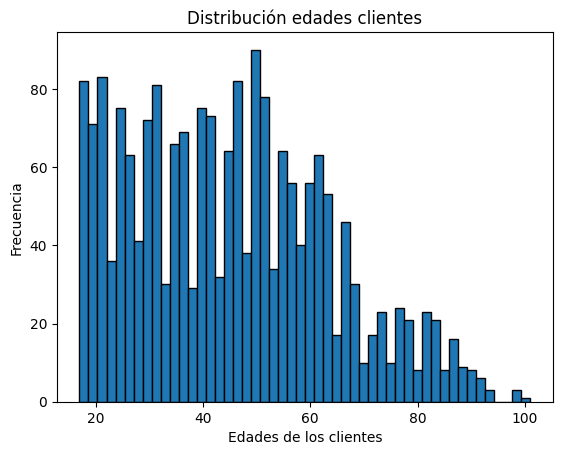

In [98]:
# Procedemos a ver cómo están distribuidos los datos de las columnas "current_age", "per_capita_income_usd"
# "yearly_income_usd", "total_debt_usd"	y "credit_score" para ver si presentan una distribución simétrica o
# presentan desviaciones hacia la izquierda o derecha.

# Para visualizar los resultados utilizamos un histograma

plt.hist(df['current_age'], bins = 50, edgecolor='black')
plt.title('Distribución edades clientes')
plt.xlabel('Edades de los clientes')
plt.ylabel('Frecuencia')
plt.show()

In [99]:
df['current_age'].median()

np.float64(44.0)

Observamos que el histograma muestra una forma aproximadamente simétrica y lo corroboramos observando que la media (45 años) y la mediana (44 años) están muy cerca entre sí.

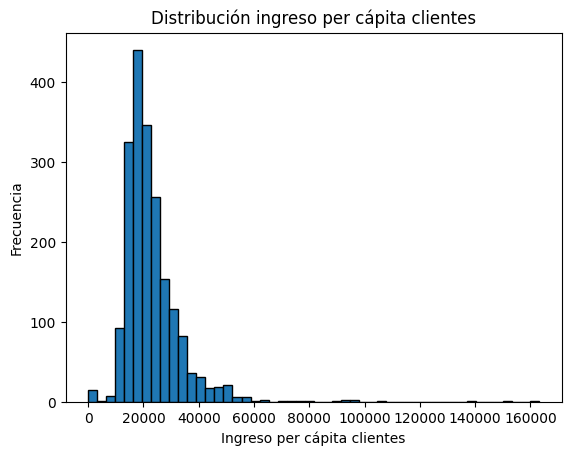

In [100]:
plt.hist(df['per_capita_income_usd'], bins = 50, edgecolor='black')
plt.title('Distribución ingreso per cápita clientes')
plt.xlabel('Ingreso per cápita clientes')
plt.ylabel('Frecuencia')
plt.show()

Observamos que el histograma no presenta una distribución simétrica, donde la mayoría de los datos están concentrados en la parte izquierda y hay una cola prolongada hacia la derecha. Este comportamiento se da al haber clientes con diferente zona de residencia, donde el ingreso per cápita mucho mayor a la media de USD 23,141.93.

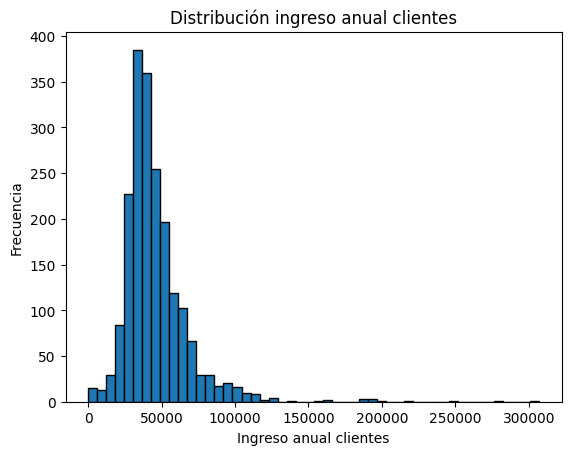

In [101]:
plt.hist(df['yearly_income_usd'], bins = 50, edgecolor='black')
plt.title('Distribución ingreso anual clientes')
plt.xlabel('Ingreso anual clientes')
plt.ylabel('Frecuencia')
plt.show()

Este histograma presenta el mismo comportamiento que el del ingreso per cápita, donde hay una gran concentración de clientes con ingresos bajos comparados con ingresos muy superiores donde el máximo es de USD 307,018. Se puede decir que este comportamiento es "normal" ya que los ingresos no son iguales para todos y hay personas que presentan ingresos bastante altos comparado con la media de ingresos.

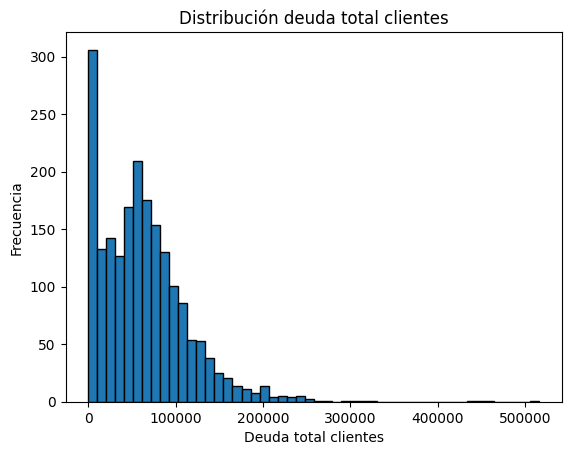

In [102]:
plt.hist(df['total_debt_usd'], bins = 50, edgecolor='black')
plt.title('Distribución deuda total clientes')
plt.xlabel('Deuda total clientes')
plt.ylabel('Frecuencia')
plt.show()

Se observa que la mayoría de clientes están acumulados en la parte izquierda de la gráfica, lo que significa que tienen una deuda baja (incluso hay varios con una deuda de valor cero). Se puede concluir que este es un comportamiento normal ya que es plausible que hayan clientes con deuda igual a cero.

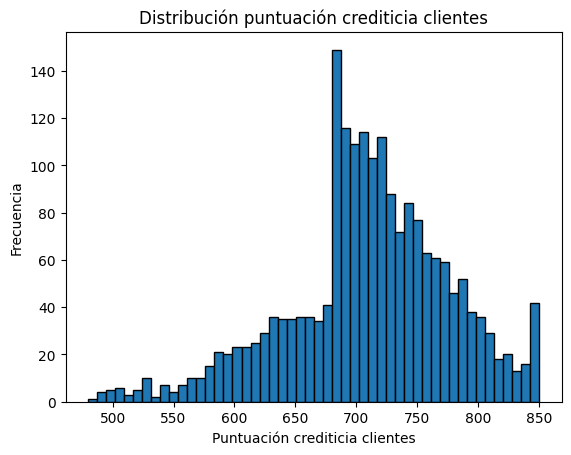

In [103]:
plt.hist(df['credit_score'], bins = 50, edgecolor='black')
plt.title('Distribución puntuación crediticia clientes')
plt.xlabel('Puntuación crediticia clientes')
plt.ylabel('Frecuencia')
plt.show()

Este histograma presenta una forma casi en forma de campana (achatada en la parte izquierda), con lo cual se puede decir que hay una cierta buen simetría, donde la distribución de los datos se concentra alrededor de 700, lo que se interpreta como una "buena" puntuación crediticia.

### Investigación de las columnas de ingresos

Se observa que los valores mínimos del ingreso anual y el ingreso per capita son USD 1 y USD 0 respectivamente, por lo que se
procede a ver los registros con esos valores. Para el análisis de los datos se asume que la columna de "per cápita income" se refiere al promedio del ingreso anual en dólares de una persona en un área geográfica específica del cliente, ya que el dataframe contiene una columna llamada "yearly income" que se refiere al ingreso anual en dólares del cliente.

In [104]:
# Cantidad clientes con un ingreso anual igual a USD 1
(df["yearly_income_usd"] == 1).sum()

np.int64(1)

In [105]:
# Detalle de los clientes con un ingreso anual igual a USD 1
df[df["yearly_income_usd"] == 1]

,id_client,current_age,birth_year,birth_month,retirement_age,sex,latitude,longitude,address,city,state,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
764,1942,77,1942,3,63,female,40.71,-73.99,2073 South Avenue,New York City,NY,United States of America,0.0,1.0,0.0,673,3


In [106]:
# Filtramos los clientes con un ingreso anual menor o igual a USD 100 para ver cuántos clientes presentan
# esta característica
df[df["yearly_income_usd"] <= 100]

,id_client,current_age,birth_year,birth_month,retirement_age,sex,latitude,longitude,address,city,state,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
764,1942,77,1942,3,63,female,40.71,-73.99,2073 South Avenue,New York City,NY,United States of America,0.0,1.0,0.0,673,3
1342,1364,47,1972,11,72,male,32.93,-97.22,37845 Main Street,Keller,TX,United States of America,0.0,3.0,5.0,750,2
1543,1202,63,1956,10,65,female,41.83,-87.68,881 Ocean View Street,Chicago,IL,United States of America,0.0,4.0,0.0,691,3
1686,1348,83,1936,6,64,male,40.64,-73.94,873 Summit Street,Brooklyn,NY,United States of America,0.0,2.0,0.0,667,6


In [107]:
# Cantidad clientes con un ingreso per capita igual a USD 0
(df["per_capita_income_usd"] == 0).sum()

np.int64(15)

In [108]:
# Detalle de los clientes con un ingreso per capita igual a USD 0
df[df["per_capita_income_usd"] == 0]

,id_client,current_age,birth_year,birth_month,retirement_age,sex,latitude,longitude,address,city,state,country,per_capita_income_usd,yearly_income_usd,total_debt_usd,credit_score,num_cards
246,1828,50,1969,6,68,male,41.83,-87.68,35 Hillside Drive,Chicago,IL,United States of America,0.0,2466.0,5521.0,711,2
662,1016,41,1978,8,53,female,32.95,-117.19,165 Fourth Street,Fairbanks Ranch,CA,United States of America,0.0,553.0,740.0,719,3
741,82,22,1997,9,68,female,41.83,-87.68,6054 Main Avenue,Chicago,IL,United States of America,0.0,2026.0,1417.0,779,1
751,1151,53,1966,12,65,male,40.35,-74.65,353 South Boulevard,Princeton,NJ,United States of America,0.0,920.0,1914.0,788,3
764,1942,77,1942,3,63,female,40.71,-73.99,2073 South Avenue,New York City,NY,United States of America,0.0,1.0,0.0,673,3
993,1481,72,1947,6,65,male,37.78,-121.99,527 Federal Avenue,San Ramon,CA,United States of America,0.0,2422.0,810.0,632,2
1068,1663,24,1995,7,59,male,41.83,-87.68,276 12th Boulevard,Chicago,IL,United States of America,0.0,2370.0,4397.0,581,1
1100,1530,63,1956,2,68,female,32.93,-97.22,25 Elm Street,Keller,TX,United States of America,0.0,1785.0,2892.0,732,3
1166,1985,50,1969,3,69,female,34.06,-84.27,9061 Grant Avenue,Alpharetta,GA,United States of America,0.0,1426.0,3154.0,680,3
1213,608,32,1987,10,65,male,37.78,-121.99,702 Grant Drive,San Ramon,CA,United States of America,0.0,2365.0,0.0,769,3


* Se observa que los registros de los clientes con un ingreso anual menor a USD 100 están contenidos también dentro de los registros de los clientes con un ingreso per cápita de USD 0.
* Los cuatro clientes con un ingreso anual menor a USD 100 presentan edades de 47, 63, 77 y 83 respectivamente, edades donde no es normal que se tenga ese tipo de ingreso anual, por lo que podrían estar errados. Habría que investigar la veracidad de estos datos.
* Los 11 clientes restantes presentan un ingreso anual entre USD 399 y USD 2,466, algo fuera de lo común, pero no imposible, pero al tener un ingreso per capita de USD 0, se presta para interpretar que estos registros puedan ser erróneos.

In [109]:
# Separamos las información de ingreso per capita, longitud, latitud, domicilio y ciudad de los registros 
# con ingreso per capita igual a USD 0 en otro dataframe y graficamos en un mapa esta información para
# ver si hay alguna relación entre estos clientes

df_1 = df[['per_capita_income_usd', 'longitude', 'latitude', 'address', 'city']]

In [110]:
per_capita_income_zero = df_1.drop(df_1[df_1['per_capita_income_usd'] != 0].index)
per_capita_income_zero

,per_capita_income_usd,longitude,latitude,address,city
246,0.0,-87.68,41.83,35 Hillside Drive,Chicago
662,0.0,-117.19,32.95,165 Fourth Street,Fairbanks Ranch
741,0.0,-87.68,41.83,6054 Main Avenue,Chicago
751,0.0,-74.65,40.35,353 South Boulevard,Princeton
764,0.0,-73.99,40.71,2073 South Avenue,New York City
993,0.0,-121.99,37.78,527 Federal Avenue,San Ramon
1068,0.0,-87.68,41.83,276 12th Boulevard,Chicago
1100,0.0,-97.22,32.93,25 Elm Street,Keller
1166,0.0,-84.27,34.06,9061 Grant Avenue,Alpharetta
1213,0.0,-121.99,37.78,702 Grant Drive,San Ramon


In [111]:
per_capita_income_zero['city'].value_counts()

city
Chicago            4
San Ramon          2
Keller             2
Fairbanks Ranch    1
Princeton          1
New York City      1
Alpharetta         1
Hillsborough       1
Brooklyn           1
Katy               1
Name: count, dtype: int64

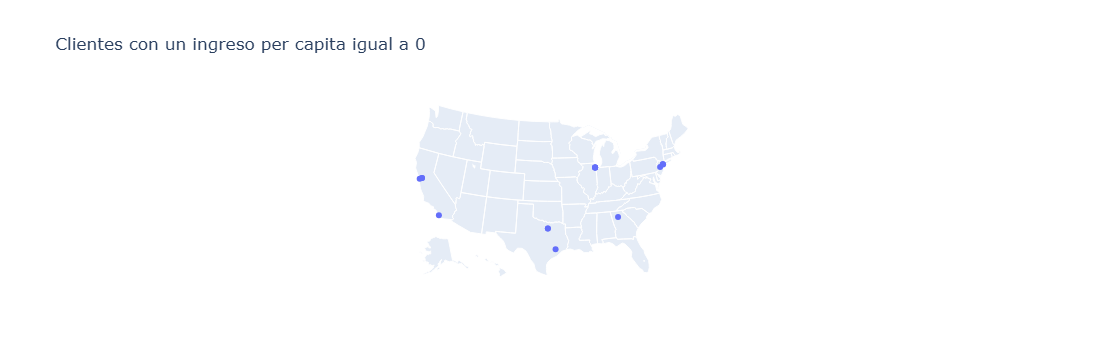

In [112]:
# Graficamos en un mapa estos puntos para saber si hay alguna relación entre ellos
# usando la libreria import plotly.graph_objects as go.
# Como los clientes son de EEUU, focalizamos la gráfica en este país

df_2 = per_capita_income_zero 
df_2['text'] = per_capita_income_zero['city']

fig = go.Figure(data=go.Scattergeo(
        lon = df_2['longitude'],
        lat = df_2['latitude'],
        text = df_2['text'],
        mode = 'markers',
        ))

fig.update_layout(
        title = 'Clientes con un ingreso per capita igual a 0',
        geo_scope = 'usa'
    )

fig.show()

Por la distribución de los clientes en el mapa, se observa que no pertenecen a una misma región, por lo que se podría descartar un posible error de recolección de datos de una zona específica.

No es claro el por qué estos registros presentan eso valores, por lo que tomamos la decisión de dejarlos en el dataframe al ser una muestra muy pequeña (0,75%) con respecto al total de registros (2000). Esto sería algo que consultar con la persona encargada de la base de datos o el Data Engineer para ver si se trata de una anomalía o por el contrario son datos bien tomados.

### Correlación entre diferentes columnas

Procedemos a analizar la correlación entre las columnas de **"per_capita_income_usd"** y **"yearly_income_usd"**. Para esto vamos a utilizar la correlación de Pearson.

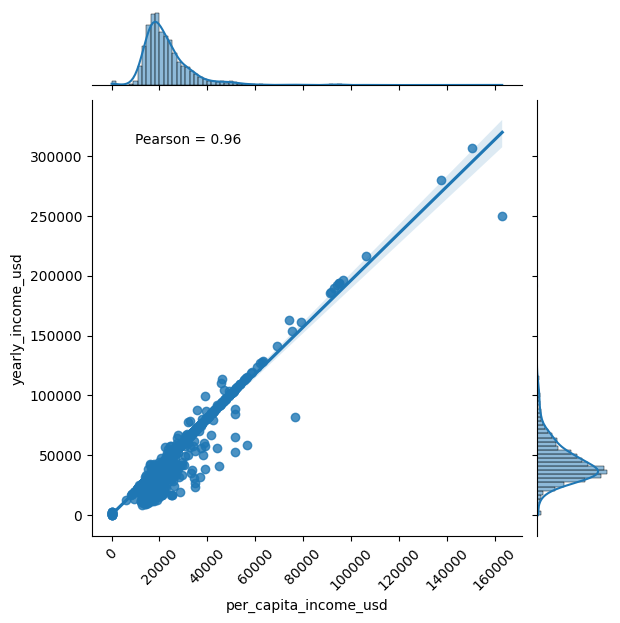

In [113]:
# Correlación de Pearson

g = sns.jointplot(data=df, x='per_capita_income_usd', y='yearly_income_usd', kind='reg')

# Calculamos el coeficiente de correlación de Pearson
r, p = pearsonr(df['per_capita_income_usd'], df['yearly_income_usd'])

# Añadimos el coeficiente de correlación de Pearson al gráfico
g.ax_joint.text(0.1, 0.9, f'Pearson = {r:.2f}', transform=g.ax_joint.transAxes)

# Mostramos el gráfico
plt.xticks(rotation=45)
plt.show()

Observamos que el coeficiente de Pearson es de 0.96, muy cercano a 1, lo que indica que hay una correlación bastante fuerte indicando que si una variable crece, la otra también, como se observa en el gráfico. Puede interpretarse que los clientes viven en zonas geográficas acorde sus ingresos anuales. Se podría usar con seguridad para predecir el crecimiento de una variable frente a la otra.

Procedemos ahora a ver como se correlacionan las columnas de **"yearly_income_usd"** y **"total_debt_usd"**

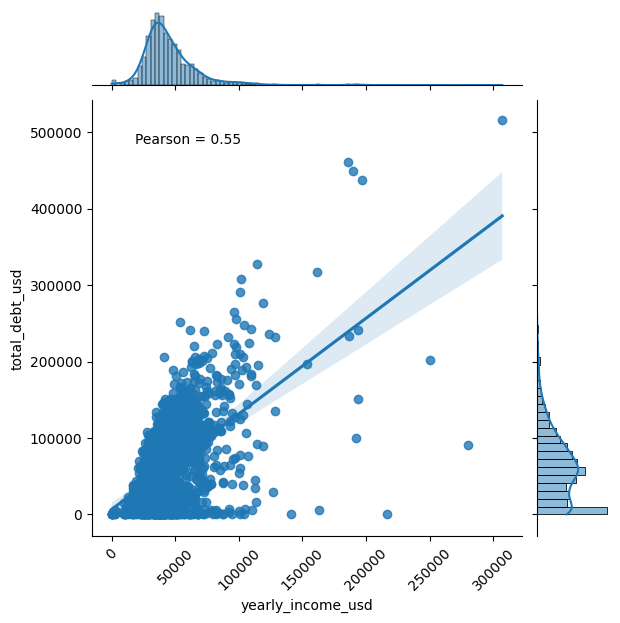

In [114]:
# Correlación de Pearson

g = sns.jointplot(data=df, x='yearly_income_usd', y='total_debt_usd', kind='reg')

# Calculamos el coeficiente de correlación de Pearson
r, p = pearsonr(df['yearly_income_usd'], df['total_debt_usd'])

# Añadimos el coeficiente de correlación de Pearson al gráfico
g.ax_joint.text(0.1, 0.9, f'Pearson = {r:.2f}', transform=g.ax_joint.transAxes)

# Mostramos el gráfico
plt.xticks(rotation=45)
plt.show()

Para este caso la correlación es de 0.55, una correlación moderada entre los ingresos anuales y la deuda total. Se puede interpretar que los clientes tienden a endeudarse más si presentan ingresos anuales mayores. Esto al principio podría interpretarse como contradictorio, pero si lo  vemos como que los clientes están dispuestos a endeudarse, siempre y cuando tengan con que pagar esa deuda, tendría sentido este comportamiento.

Procedemos a ver la correlación que existe entre la columna **"current_age"** y **"total_debt_usd"**

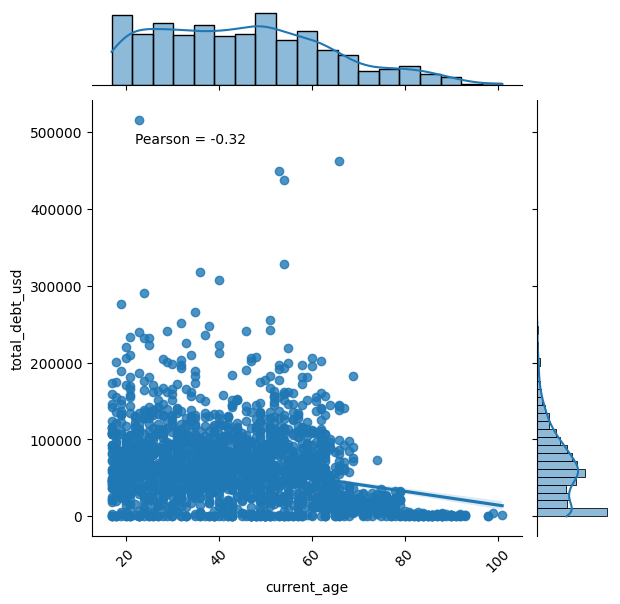

In [115]:
# Correlación de Pearson

g = sns.jointplot(data=df, x='current_age', y='total_debt_usd', kind='reg')

# Calculamos el coeficiente de correlación de Pearson
r, p = pearsonr(df['current_age'], df['total_debt_usd'])

# Añadimos el coeficiente de correlación de Pearson al gráfico
g.ax_joint.text(0.1, 0.9, f'Pearson = {r:.2f}', transform=g.ax_joint.transAxes)

# Mostramos el gráfico
plt.xticks(rotation=45)
plt.show()

Podemos observar que por el valor del coeficiente de Pearson, hay una relación negativa debil más cerca a cero entre ambas variables. Se observa que a medida que la edad avanza, la deuda tiende a disminuir. Se puede interpretar que las personas en edades tempranas tienden a gastar más que las personas de edad avanzada, tal vez porque tienen más actividades y gastos en esta franja de edad que en la franja final.

Ahora procedemos a analizar que relación hay entre la **deuda total** que tiene cada cliente con respecto a las columnas de **'yearly_income_usd'**, **'current_age'**, **'credit_score'**, y **'num_credit_cards'**, para eso creamos la matriz de correlación de Pearson.

In [116]:
# matriz de correlación de Pearson
df[['total_debt_usd', 'yearly_income_usd', 'current_age', 'credit_score', 'num_cards']].corr(method='pearson').round(2)

,total_debt_usd,yearly_income_usd,current_age,credit_score,num_cards
total_debt_usd,1.00,0.55,-0.32,-0.10,-0.22
yearly_income_usd,0.55,1.00,-0.11,0.00,-0.03
current_age,-0.32,-0.11,1.00,-0.01,0.48
credit_score,-0.10,0.00,-0.01,1.00,0.24
num_cards,-0.22,-0.03,0.48,0.24,1.00


* Se observa que la variable con la que se presenta una correlación más fuerte es con "yearly_income_usd", es decir que los clientes con mayores ingresos tienden a tener una deuda mayor. Esto ya lo pudimos observar en la gráfica de correlación que obtuvimos anteriormente.
* Con respecto a la variable "current_age", como se observó en la gráfica de correlación, el coeficiente indica una correlación negativa y se podría interpretar que en edades tempranas se tiende a gastar más que en edades mayores.
* Con respecto a la variable de "credit_score" se observa que hay una correlación negativa débil (muy cerca de 0), por lo que se podría decir que el puntaje crediticio no está directamente relacionado con la cantidad de deuda que tiene el cliente, tal vez sí en que tan responsable es el cliente en pagar su deuda.
* Con respecto a la variable "num_cards", se presenta también una correlación negativa débil, se podría decir que los clientes con mayor cantidad de tarjetas, tienden a tener una menor deuda, tal vez porque los clientes que tienen un mayor número de tarjetas suelen hacer un buen manejo de sus pagos.

## Tablas limpias a conectar con MySQL Workbench y a exportar a formato .csv

* Exploramos la información general de los dataframes a conectar con MySQL Workbench y a exportar en formato .csv

In [117]:
dataframe_list = [city, country, state_usa, users]
dataframe_name = ['city', 'country', 'state_usa', 'users']

for i, df in enumerate(dataframe_list):
    print('\n', f'dataframe ** {dataframe_name[i]} **:')
    print(df.info(show_counts=True), '\n')


 dataframe ** city **:
<class 'pandas.DataFrame'>
RangeIndex: 11306 entries, 0 to 11305
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id_city  11306 non-null  int64
 1   city     11306 non-null  str  
dtypes: int64(1), str(1)
memory usage: 176.8 KB
None 


 dataframe ** country **:
<class 'pandas.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   id_country  114 non-null    int64
 1   country     114 non-null    str  
dtypes: int64(1), str(1)
memory usage: 1.9 KB
None 


 dataframe ** state_usa **:
<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   id_state_usa            52 non-null     int64
 1   abbreviation_state_usa  52 non-null     str  
 2   name_state_usa        

* Cambiamos el directorio de trabajo a 'FILES_DIRECTORY' porque allí exportaremos las tablas 'limpias' en formato .csv

In [118]:
os.chdir(FILES_DIRECTORY)

In [119]:
# Chequeamos el directorio actual de trabajo

In [120]:
pwd!

'C:\\Users\\yanig\\Python_Unicorn\\Proyecto_integrador\\files'

* Exportamos de las tablas 'limpias' a formato .csv

In [121]:
city.to_csv('city.csv', index=False)
country.to_csv('country.csv', index=False)
state_usa.to_csv('state_usa.csv', index=False)
users.to_csv('users.csv', index=False)

In [ ]:
DAX
Financial Risk Score =

VAR DebtRatio =
    AVERAGE(users[debt_to_income_ratio])

VAR CreditScore =
    AVERAGE(users[credit_score])

VAR DebtRisk =
    SWITCH(
        TRUE(),
        DebtRatio >= 0.60, 5,
        DebtRatio >= 0.45, 4,
        DebtRatio >= 0.30, 3,
        DebtRatio >= 0.20, 2,
        1
    )

VAR CreditRisk =
    SWITCH(
        TRUE(),
        CreditScore < 580, 5,
        CreditScore < 670, 4,
        CreditScore < 740, 3,
        CreditScore < 800, 2,
        1
    )

RETURN
ROUND(
    (DebtRisk * 0.6) +
    (CreditRisk * 0.4),
    2
)